# Forecast Evolution Analysis (v2)
This notebook allows the user to interactively plot the "Linus plot" showing forecast evolution for a specific validity date. Tested on *IFS CF*, *AIFS Single*, *IFS ENS* and *AIFS ENS* forecasts.

## User Configuration Options

- **Parameter**: Select from dropdown list
- **Forecast Settings**: 
  - Validity date (calendar picker)
  - Validity time (dropdown)
  - Step interval (dropdown)
  - Maximum forecast days (slider)
- **Model Selection**:
  - **Predefined models**: Select from the list of known models (IFS Control, AIFS Single, etc.)
  - **Custom MARS models**: Define your own model by specifying MARS retrieval arguments (`class`, `type`, `stream`, `expver`) plus optional extra keys (`model`, `database`, `grid`, ...)
- **Geographic Area**: Select using the interactive map

### Model Selection Methods

#### Predefined Models
Select one or more models from the list on the left. These have pre-configured MARS retrieval settings and plot styles.

#### Custom MARS Models
Use the panel on the right to add a model by specifying its MARS retrieval arguments:
- **Name**: A display name for the model
- **class**: MARS class (e.g. `od`, `ai`, `rd`)
- **type**: Forecast type (`fc`, `cf`, `pf`)
- **stream**: Data stream (`oper`, `enfo`, ...)
- **expver**: Experiment version (optional)
- **Ensemble**: Tick if this is an ensemble (perturbed) forecast
- **Extra MARS arguments**: Add any additional key-value pairs (e.g. `model=aifs-single`, `database=...`, `grid=[0.25,0.25]`)

### Area Selection Methods

#### Polygon Selection
When drawing a polygon, the system creates a bounding box using the northernmost, westernmost, southernmost, and easternmost points of your selection.

#### Point Selection
When selecting a single point, the system creates a ±0.5° box around that location.

In [1]:
import os
import sys

notebook_dir="/path/to/this/current/directory"  # <-- Update this to the actual path of the notebook directory
sys.path.insert(0, notebook_dir)

base_path = os.path.join(notebook_dir, "data_files")

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# Set up the interface and get the widgets dictionary
widgets_dict = setup_interface()

Please configure your forecast settings:


## Step 1 — Optional Configuration Overrides

You can programmatically override the widget selections before retrieving data.
Uncomment and adjust any of the lines below to set:

- **Area / point** — bounding box `[N, W, S, E]` or a single `[lat, lon]` point
- **Forecast range** — `max_days` and `step_interval`

#### Important Note:
When manually overriding the point's coordinates `widgets_dict['config']['point'] = [lat, lon]` make sure it is within `widgets_dict['config']['area_sub']` (if not update `widgets_dict['config']['area_sub']` as well)

In [10]:
# Optional: override configuration programmatically
#widgets_dict['config']['area_sub'] = [41.17439, -74.49292, 40.17439, -73.49292]
#widgets_dict['config']['point'] = [40.6744, -73.9929]
#widgets_dict['config']['max_days'] = 4
#widgets_dict['config']['step_interval'] = 12


## Step 2 — Optional Custom Models

Register additional models at runtime by specifying their MARS retrieval arguments.
Each model needs a unique **name**, a dict of MARS keys, and a plot colour.

In [ ]:
# Optional: add custom models programmatically instead of using the UI
# from diag_evo import register_custom_model
# register_custom_model(
#     name='AIFS_Experiment',
#     retrieval_args={
#         'class': 'rd',
#         'type': 'fc',
#         'stream': 'oper',
#         'expver': '0080',
#         'model': 'some-model',
#     },
#     is_ensemble=False,
#     color='#ff6600'
# )

## Step 3 — Retrieve Data

Fetch observations, analysis, climatology, and model forecasts via MARS.
Results are cached locally so re-running the cell is fast.

In [ ]:
plot_data = retrieve_and_store_data(widgets_dict, base_path)

Retrieving observations...
Loading existing observation files from /perm/ecm3468/testing_repo/diag_evo/data_files/2t_N41.17439_W-74.49292_S40.17439_E-73.49292_20260303/obs_files/STVL_2t_20260303_1200.grib
Nearest station (stnid: 72503, elevation: 9.0,lat: 40.77, lon: -73.9, distance: 13.20 km, value: 272.60): stnid                      72503
latitude                   40.77
longitude                  -73.9
level                        0.0
date         2026-03-03 12:00:00
elevation                    9.0
value_0                    272.6
distance               13.202041
Name: 7019, dtype: object
OBS value: 272.60
Station ID: 72503
Station elevation: 9.0 m
Station latitude: 40.77°
Station longitude: -73.9°
Retrieving analysis...
Analysis file exists, reading with metview...
Analysis units: K
Converting 2t from K to °C using subtract_273.15
The nearest grid point is at 4.711km from the selected point
Climatology file exists, reading with metview...
Converting 2t from K to °C using subtract

/perm/ecm3468/testing_repo/diag_evo/diag_evo/core.py:1350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_df = pd.concat([reference_row, data_df], ignore_index=True)


## Step 4 — Interactive Plot (Plotly)

Generate the forecast evolution box-plot with hover info (bias, lead time, member index).
The plot is also exported as a standalone HTML file.

In [3]:
area_str = get_area_string(widgets_dict['config']['area_sub'])
date_str = widgets_dict['config']['valid_date'].strftime("%Y%m%d")
_, _, plot_dir = setup_data_directories(base_path, widgets_dict['config']['param'], area_str, date_str)
plot_data['data_df'].to_csv(f'{plot_dir}/plot_data.csv', index=False)

# Create the interactive plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /perm/ecm3468/testing_repo/diag_evo/data_files/2t_N41.17439_W-74.49292_S40.17439_E-73.49292_20260303/plot_files/forecast_evolution_point_40.6744N_-73.9929E_20260303_1200_2t.html


## Step 5 — Static Plot (Matplotlib)

Percentile-box view (1/10/25/50/75/90/99) with an inset map showing the selected area or point.
Exported as a PNG file.

Static plot exported to: /perm/ecm3468/testing_repo/diag_evo/data_files/2t_N41.17439_W-74.49292_S40.17439_E-73.49292_20260303/plot_files/forecast_evolution_static_point_40.6744N_-73.9929E_20260303_1200_2t.png


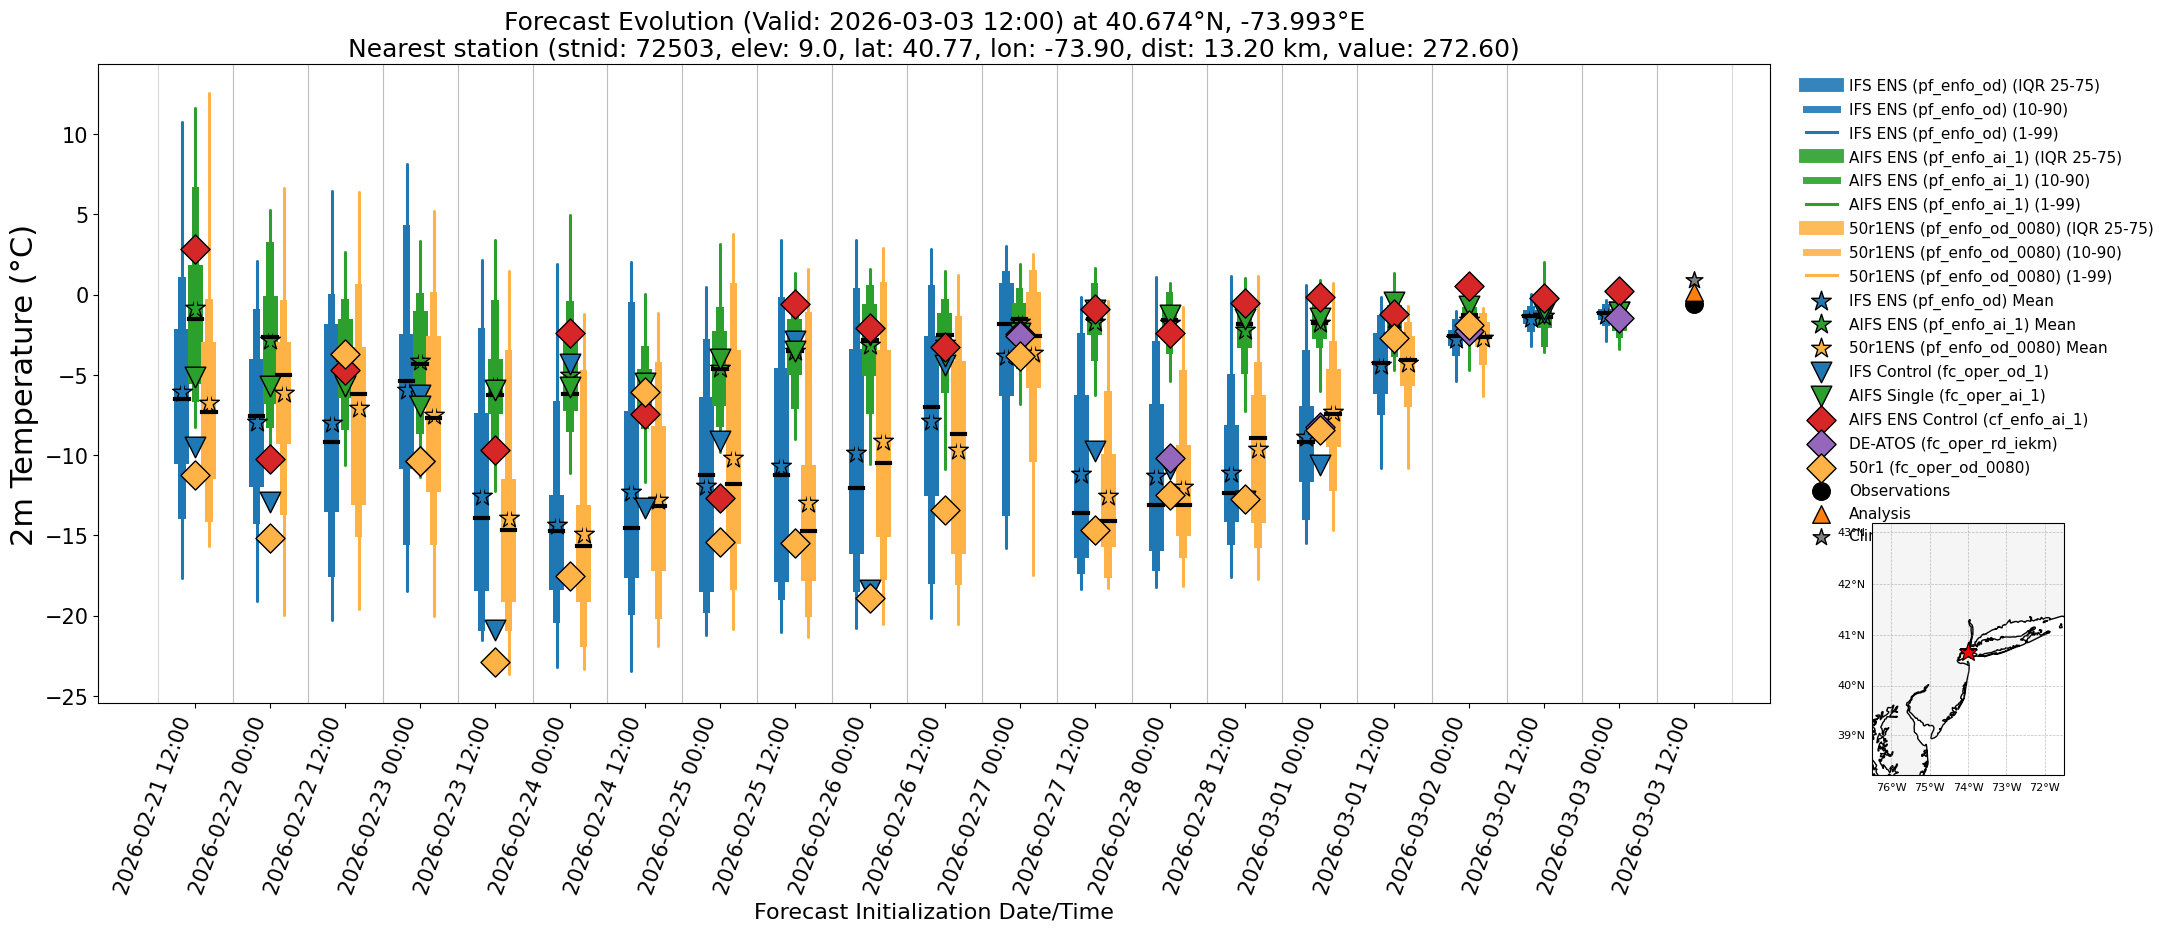

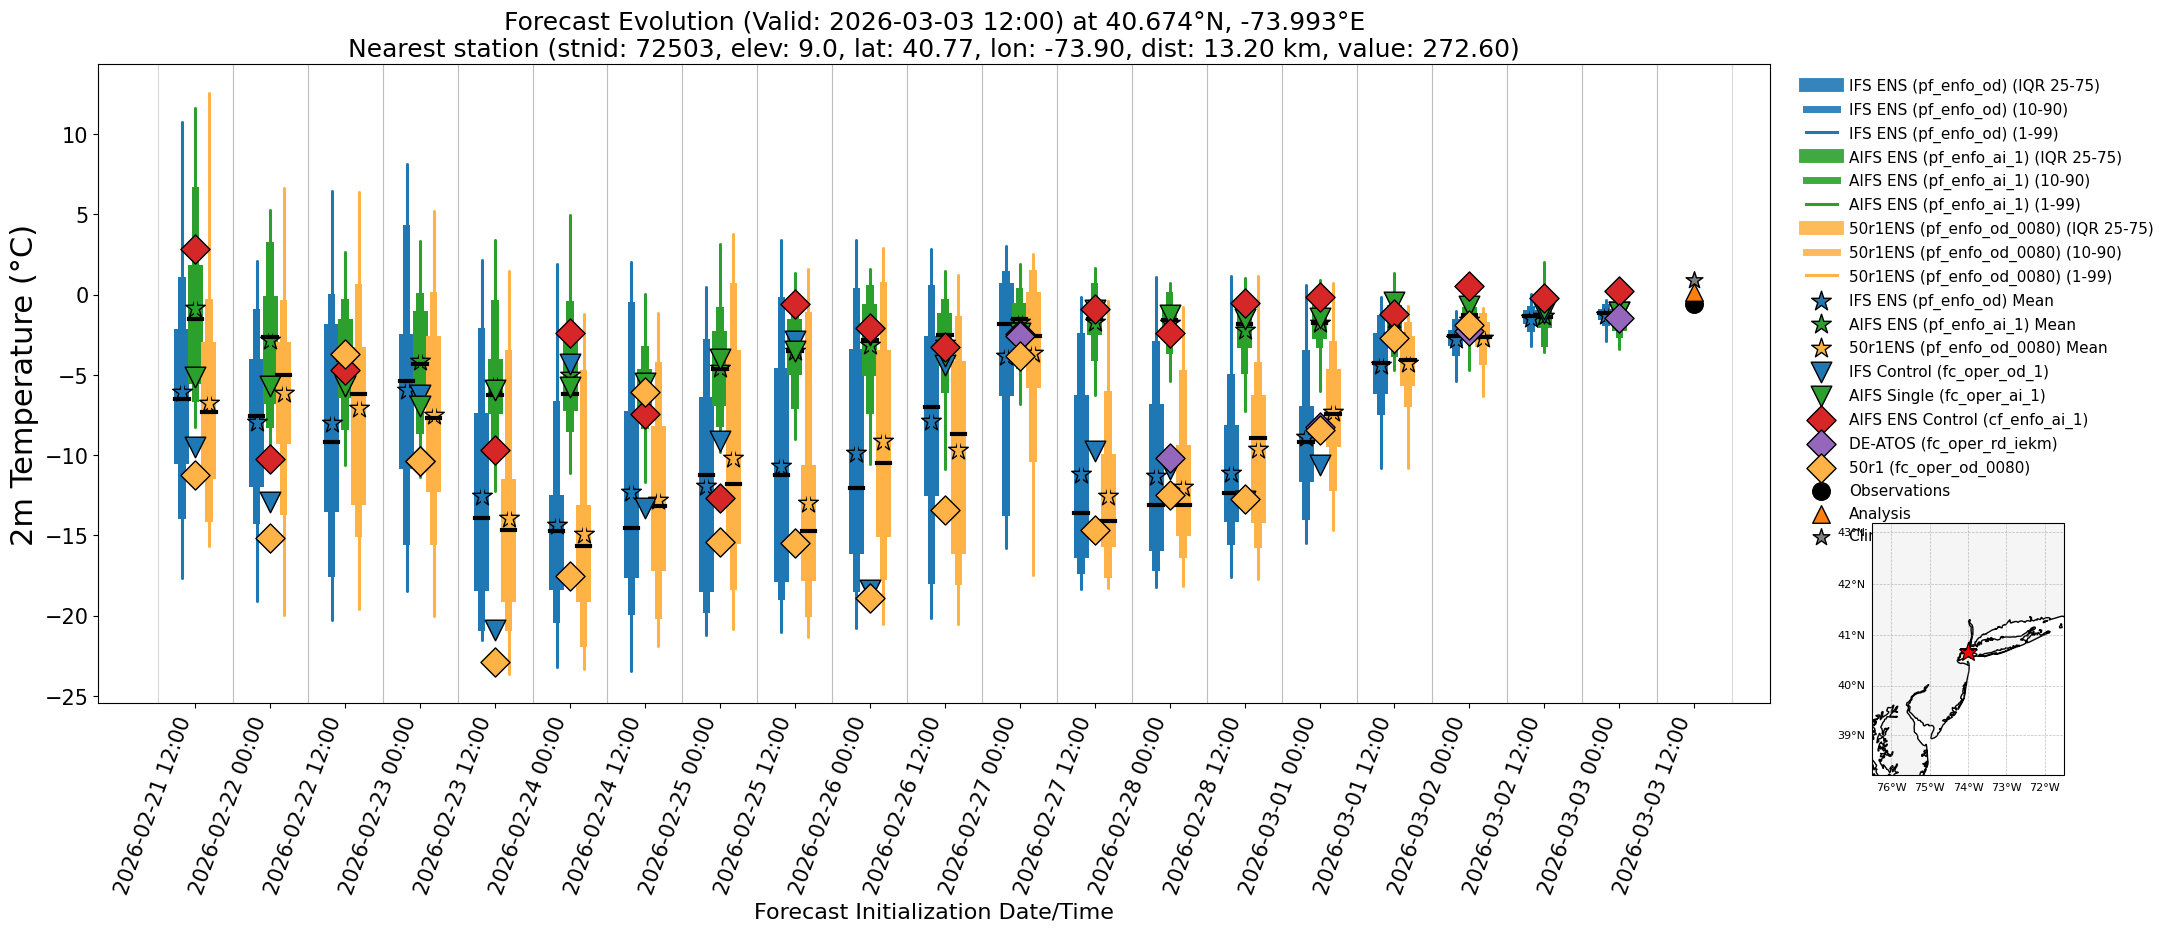

In [13]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

## Optional — Colour Overrides

Override the default plot colours per model before re-plotting.
Set `widgets_dict['config']['model_colors']` to a dict mapping model names to hex colours, then re-run a plot cell above.

In [14]:
from diag_evo import get_model_plot_settings

# Build a color map for all selected models
color_map = {}
for model_name in widgets_dict['model_widgets'].value:
    plot_cfg = get_model_plot_settings(model_name)
    color_map[model_name] = plot_cfg['color']

widgets_dict['config']['model_colors'] = color_map

In [15]:
widgets_dict['config']['model_colors']={'IFS Control': "#e0a7e9",
 'AIFS Single': "#93190c",
 'AIFS ENS Control': '#00FF1E',
 'IFS ENS': "#1e837f",
 'AIFS ENS': "#2c32a0",
 '50r1': "#8f8f0c",
 '50r1ENS': "#ffd500",
 }

Static plot exported to: /perm/ecm3468/testing_repo/diag_evo/data_files/2t_N41.17439_W-74.49292_S40.17439_E-73.49292_20260303/plot_files/forecast_evolution_static_point_40.6744N_-73.9929E_20260303_1200_2t.png


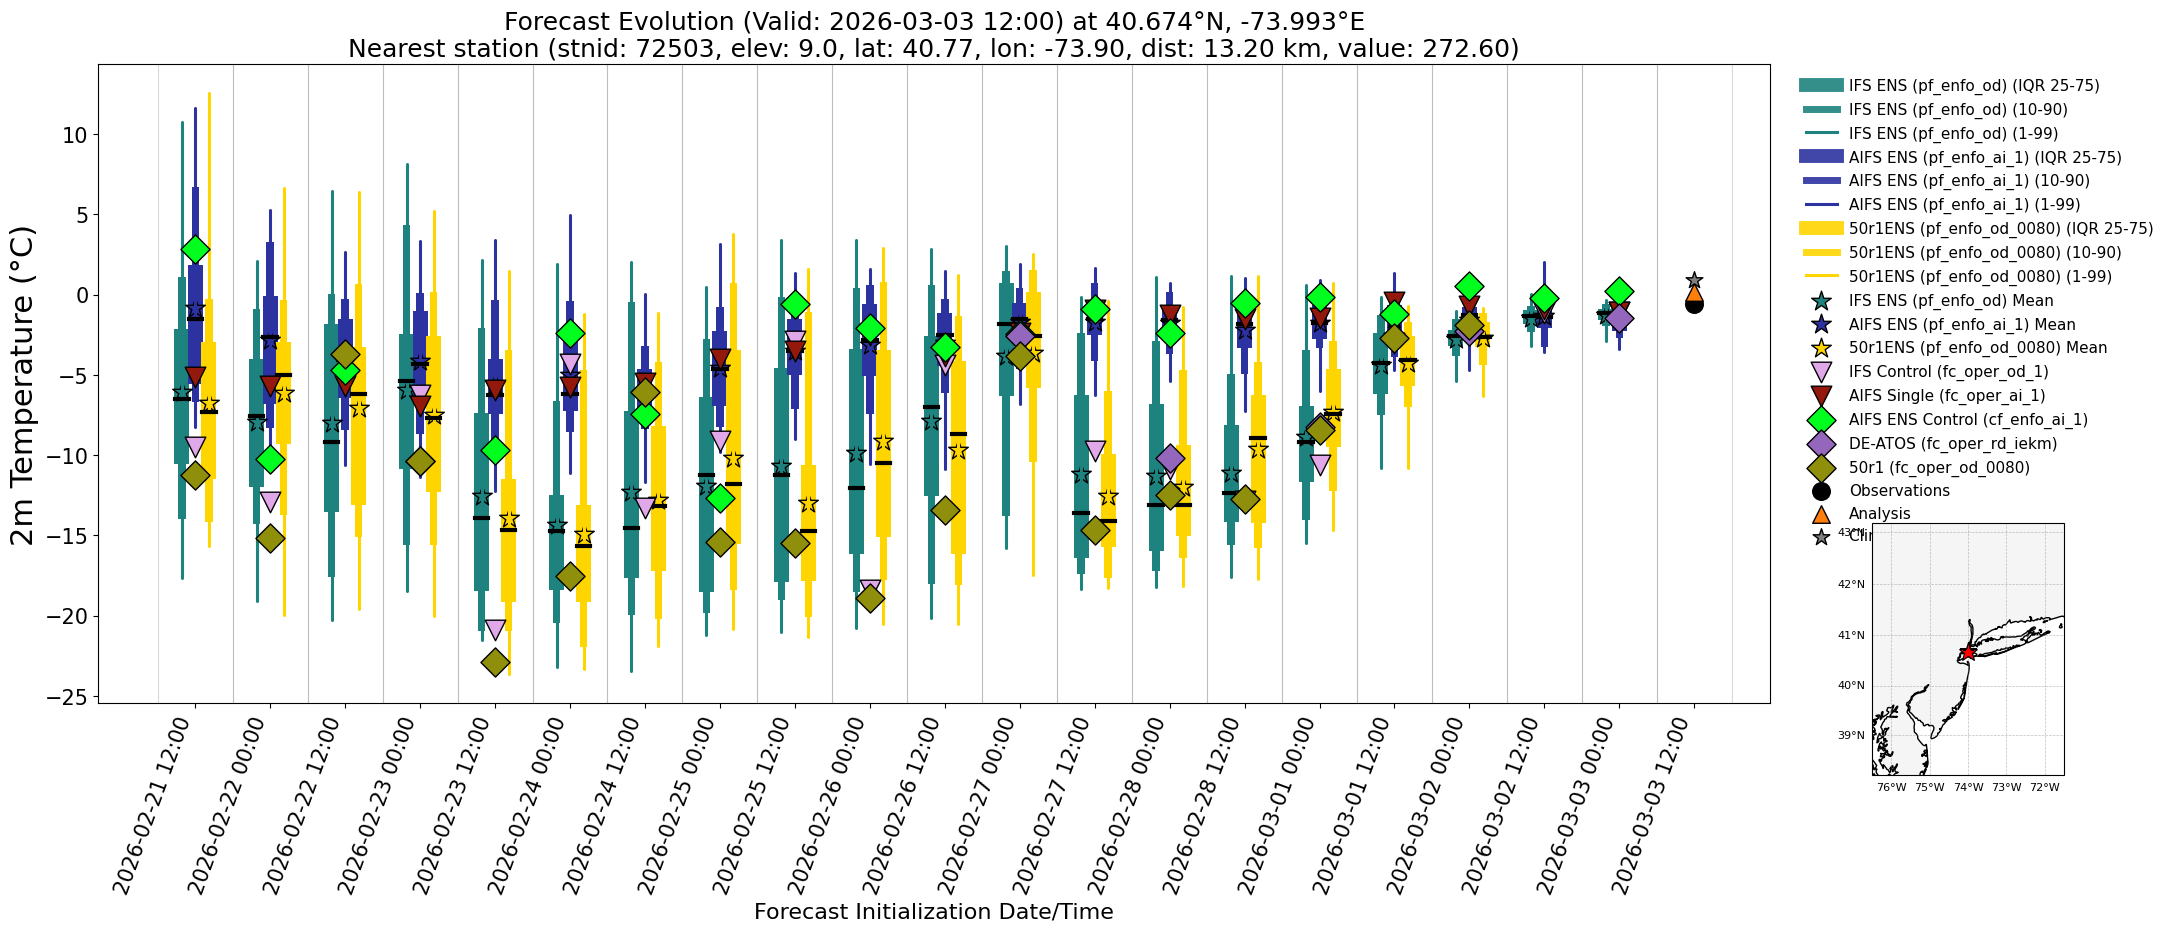

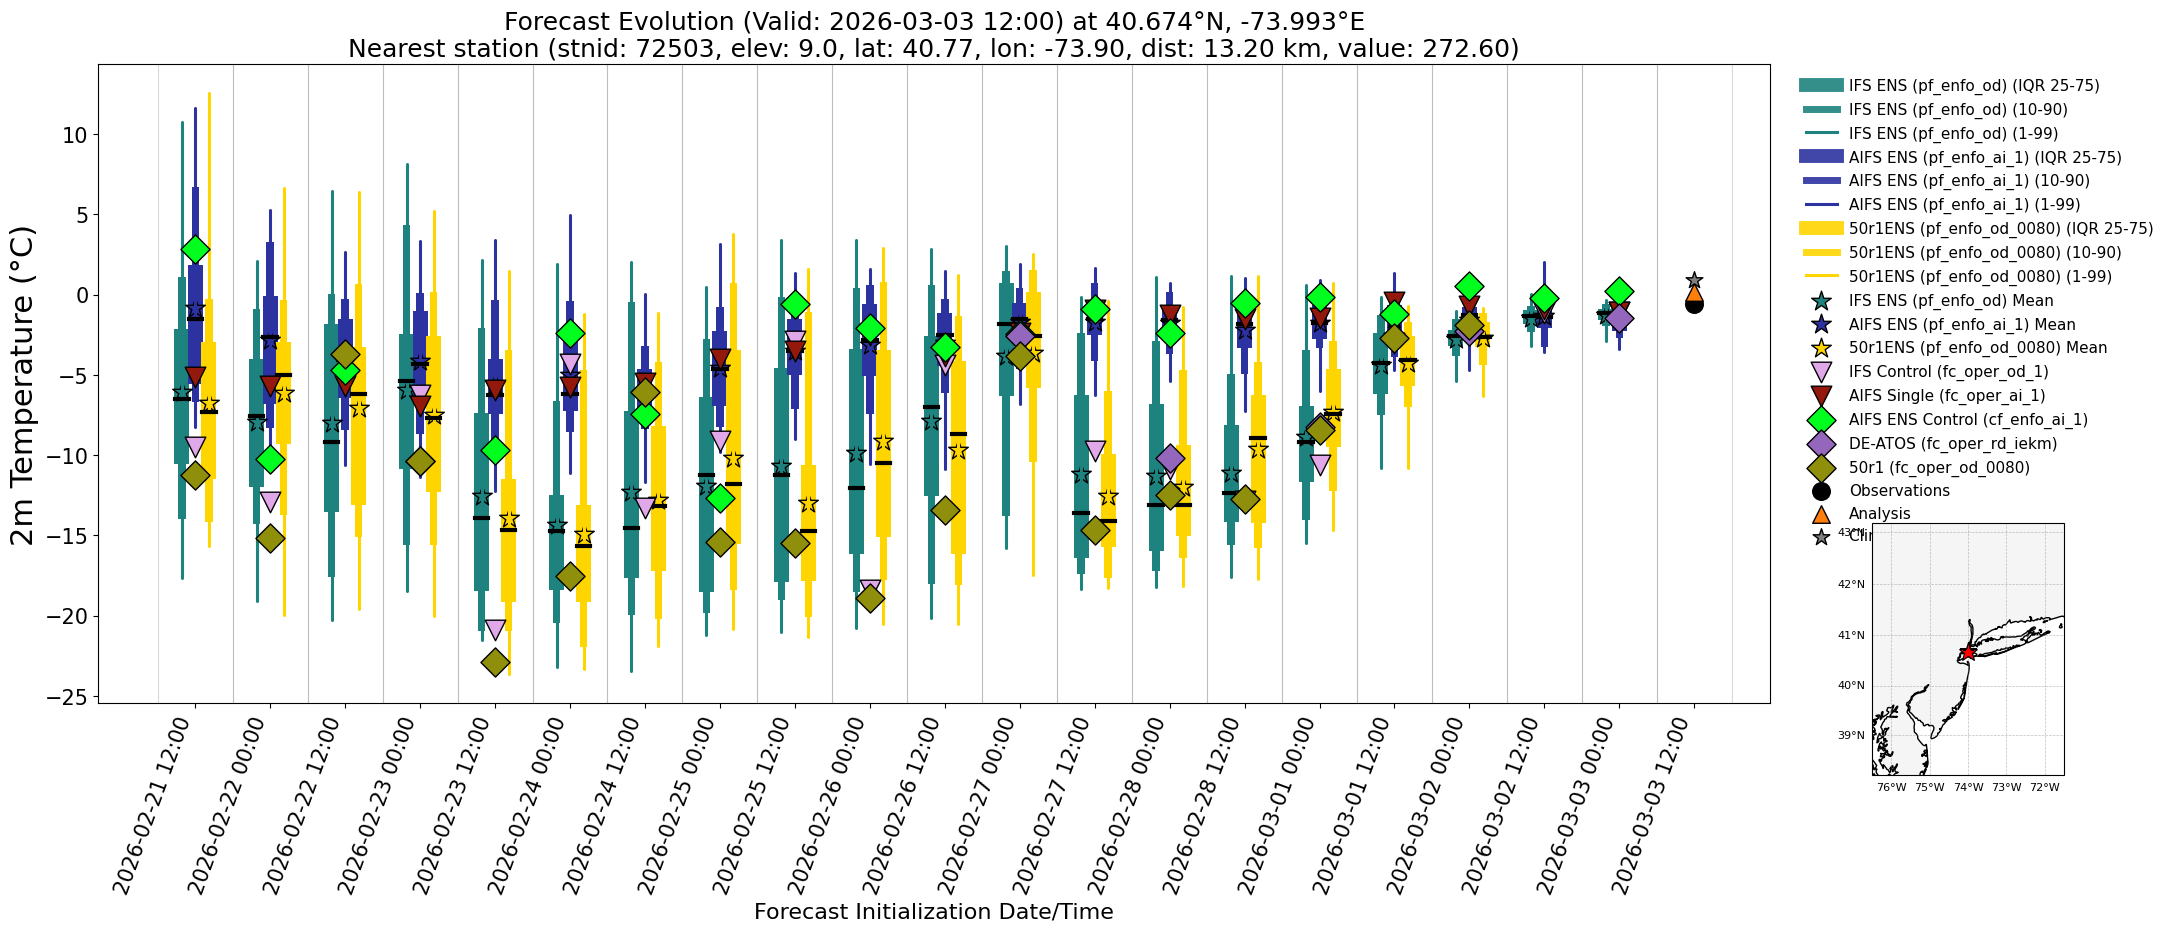

In [16]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

In [17]:
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /perm/ecm3468/testing_repo/diag_evo/data_files/2t_N41.17439_W-74.49292_S40.17439_E-73.49292_20260303/plot_files/forecast_evolution_point_40.6744N_-73.9929E_20260303_1200_2t.html


# Future updates

- Handle wind speed / gusts variables (e.g. 10ff, 100ff)
- Add weighting by cos(lat) for area averaging in case user selects a large area
- Add newly added parameters to cycle 50r1 ([50r1 implementation page](https://confluence.ecmwf.int/display/FCST/Implementation+of+IFS+Cycle+50r1))
- Map plotting features
- Add possibility to send batch job after using UI to select models and area/point
- Min/Max over certain period of time
- Automatically update 'area_sub' when user manually selects 'point'
- Add details of pl params to variable_settings.json ([Table 9](https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation#ERA5:datadocumentation-Table9))